<a href="https://colab.research.google.com/github/patriciaruizpaz/clinical-deterioration-intelligence/blob/main/notebooks/01_exploracion_limpieza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
# ============================================
# CELDA 1 — Montar Drive
# ============================================
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
# ============================================
# CELDA 2 — Configurar git y clonar el repo (limpio, sin duplicar carpetas)
# ============================================
from getpass import getpass
import os

TOKEN = getpass("Pegá tu token de GitHub: ")

!git config --global user.email "patricia.megi@gmail.com"
!git config --global user.name "patriciaruizpaz"

if os.path.exists('/content/clinical-deterioration-intelligence'):
    !rm -rf /content/clinical-deterioration-intelligence

%cd /content
!git clone https://{TOKEN}@github.com/patriciaruizpaz/clinical-deterioration-intelligence.git
%cd clinical-deterioration-intelligence
!pwd

Pegá tu token de GitHub: ··········
/content
Cloning into 'clinical-deterioration-intelligence'...
remote: Enumerating objects: 48, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 48 (delta 15), reused 38 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (48/48), 13.15 MiB | 14.84 MiB/s, done.
Resolving deltas: 100% (15/15), done.
/content/clinical-deterioration-intelligence
/content/clinical-deterioration-intelligence


In [25]:
# ============================================
# CELDA 3 — Fase 4: reproducibilidad y setup técnico
# ============================================
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)
random.seed(42)
sns.set_theme(style="whitegrid")

print("Setup completo ✅")

Setup completo ✅


In [26]:
# ============================================
# CELDA 4 — Leer los datos desde Drive
# ============================================
ruta = '/content/drive/MyDrive/Portfolio_Datos/clinical-deterioration-intelligence/data/raw/'

patients = pd.read_csv(ruta + 'patients.csv')
vitals = pd.read_csv(ruta + 'vitals_timeseries.csv')
labs = pd.read_csv(ruta + 'labs_timeseries.csv')

print(patients.shape, vitals.shape, labs.shape)

(10000, 10) (417866, 12) (417866, 8)


In [27]:
# ============================================
# CELDA 5 — Generar requirements.txt
# ============================================
!pip freeze > requirements.txt
!git add requirements.txt
!git commit -m "docs: agrega requirements.txt"
!git push origin main

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date


In [28]:
# ============================================
# Fase 5 — Paso 1: primer vistazo (muestra chica)
# ============================================
patients_sample = pd.read_csv(ruta + 'patients.csv', nrows=1000)
vitals_sample = pd.read_csv(ruta + 'vitals_timeseries.csv', nrows=1000)
labs_sample = pd.read_csv(ruta + 'labs_timeseries.csv', nrows=1000)

print("PATIENTS"); print(patients_sample.info())
print("\nVITALS"); print(vitals_sample.info())
print("\nLABS"); print(labs_sample.info())

PATIENTS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   patient_id                               1000 non-null   int64  
 1   age                                      1000 non-null   int64  
 2   gender                                   1000 non-null   object 
 3   comorbidity_index                        1000 non-null   int64  
 4   admission_type                           1000 non-null   object 
 5   baseline_risk_score                      1000 non-null   float64
 6   los_hours                                1000 non-null   int64  
 7   deterioration_event                      1000 non-null   int64  
 8   deterioration_within_12h_from_admission  1000 non-null   int64  
 9   deterioration_hour                       1000 non-null   int64  
dtypes: float64(1), int64(7), object(2)
memor

In [29]:
patients_sample.head()

,patient_id,age,gender,comorbidity_index,admission_type,baseline_risk_score,los_hours,deterioration_event,deterioration_within_12h_from_admission,deterioration_hour
0,1,24,M,2,Elective,0.2173,17,0,0,-1
1,2,74,F,3,Transfer,0.5558,33,1,0,16
2,3,65,F,7,ED,0.6325,55,0,0,-1
3,4,50,M,0,ED,0.2896,37,0,0,-1
4,5,49,M,0,ED,0.2507,22,0,0,-1


In [30]:
vitals_sample.head()

,patient_id,hour_from_admission,heart_rate,respiratory_rate,spo2_pct,temperature_c,systolic_bp,diastolic_bp,oxygen_device,oxygen_flow,mobility_score,nurse_alert
0,1,0,68.58,14.47,96.52,37.18,108.94,78.43,none,0.0,2,0
1,1,1,67.03,13.87,94.94,37.25,111.73,79.14,none,0.0,3,0
2,1,2,69.05,14.63,94.45,37.29,111.48,78.86,none,0.0,2,0
3,1,3,69.07,14.42,95.16,37.27,110.68,76.79,none,0.0,2,0
4,1,4,73.35,15.62,95.83,37.21,110.38,75.47,none,0.0,3,0


In [31]:
labs_sample.head()

,patient_id,hour_from_admission,wbc_count,lactate,creatinine,crp_level,hemoglobin,sepsis_risk_score
0,1,0,5.68,1.28,1.27,10.66,13.55,0.2621
1,1,1,5.46,1.18,1.22,11.94,13.65,0.3353
2,1,2,5.55,1.21,1.25,10.24,13.69,0.1678
3,1,3,5.50,1.13,1.24,10.72,13.61,0.1961
4,1,4,5.96,1.20,1.21,11.46,13.49,0.3000


In [32]:
# ============================================
# Fase 5 — Paso 3: validar hipótesis contra la realidad
# ============================================
print(vitals.columns.tolist())

['patient_id', 'hour_from_admission', 'heart_rate', 'respiratory_rate', 'spo2_pct', 'temperature_c', 'systolic_bp', 'diastolic_bp', 'oxygen_device', 'oxygen_flow', 'mobility_score', 'nurse_alert']


In [33]:
filas_por_paciente_vitals = vitals.groupby('patient_id').size()
filas_por_paciente_labs = labs.groupby('patient_id').size()

print("Vitals — filas por paciente (promedio):", filas_por_paciente_vitals.mean())
print("Labs — filas por paciente (promedio):", filas_por_paciente_labs.mean())

Vitals — filas por paciente (promedio): 41.7866
Labs — filas por paciente (promedio): 41.7866


In [34]:
# Consistencia de patient_id entre las 3 tablas (versión correcta, sin bug de muestra)
ids_patients = set(patients['patient_id'])
ids_vitals = set(vitals['patient_id'])

print("Pacientes en patients.csv pero NO en vitals:", len(ids_patients - ids_vitals))
print("Pacientes en vitals pero NO en patients.csv:", len(ids_vitals - ids_patients))

Pacientes en patients.csv pero NO en vitals: 0
Pacientes en vitals pero NO en patients.csv: 0


In [35]:
duplicados_vitals = vitals.duplicated(subset=['patient_id', 'hour_from_admission']).sum()
print("Filas duplicadas de la PK compuesta en vitals:", duplicados_vitals)

Filas duplicadas de la PK compuesta en vitals: 0


In [36]:
prueba_join = vitals_sample.merge(labs_sample, on=['patient_id', 'hour_from_admission'], how='inner')
print(len(vitals_sample), len(labs_sample), len(prueba_join))

1000 1000 1000


In [37]:
# ============================================
# Fase 6 — Auditoría de calidad de datos
# ============================================
print("PATIENTS — % nulos"); print((patients.isnull().sum() / len(patients) * 100).round(2))
print("\nVITALS — % nulos"); print((vitals.isnull().sum() / len(vitals) * 100).round(2))
print("\nLABS — % nulos"); print((labs.isnull().sum() / len(labs) * 100).round(2))

PATIENTS — % nulos
patient_id                                 0.0
age                                        0.0
gender                                     0.0
comorbidity_index                          0.0
admission_type                             0.0
baseline_risk_score                        0.0
los_hours                                  0.0
deterioration_event                        0.0
deterioration_within_12h_from_admission    0.0
deterioration_hour                         0.0
dtype: float64

VITALS — % nulos
patient_id             0.0
hour_from_admission    0.0
heart_rate             0.0
respiratory_rate       0.0
spo2_pct               0.0
temperature_c          0.0
systolic_bp            0.0
diastolic_bp           0.0
oxygen_device          0.0
oxygen_flow            0.0
mobility_score         0.0
nurse_alert            0.0
dtype: float64

LABS — % nulos
patient_id             0.0
hour_from_admission    0.0
wbc_count              0.0
lactate                0.0
creatinine     

In [38]:
print(patients.duplicated().sum(), vitals.duplicated().sum(), labs.duplicated().sum())

0 0 0


In [39]:
columnas_vitales = ['heart_rate', 'respiratory_rate', 'spo2_pct', 'temperature_c', 'systolic_bp', 'diastolic_bp']
print(vitals[columnas_vitales].describe().round(2))

       heart_rate  respiratory_rate   spo2_pct  temperature_c  systolic_bp  \
count   417866.00         417866.00  417866.00      417866.00    417866.00   
mean        89.26             20.18      93.50          36.97       113.40   
std         21.13              6.85       5.95           0.45        17.11   
min         40.00              8.00      70.00          35.24        70.00   
25%         76.92             15.86      92.51          36.70       103.98   
50%         86.33             19.33      94.83          36.92       114.83   
75%         96.86             23.04      96.85          37.15       124.85   
max        180.00             45.00     100.00          40.50       184.56   

       diastolic_bp  
count     417866.00  
mean          70.52  
std           10.67  
min           40.00  
25%           65.02  
50%           71.47  
75%           77.44  
max          110.00  


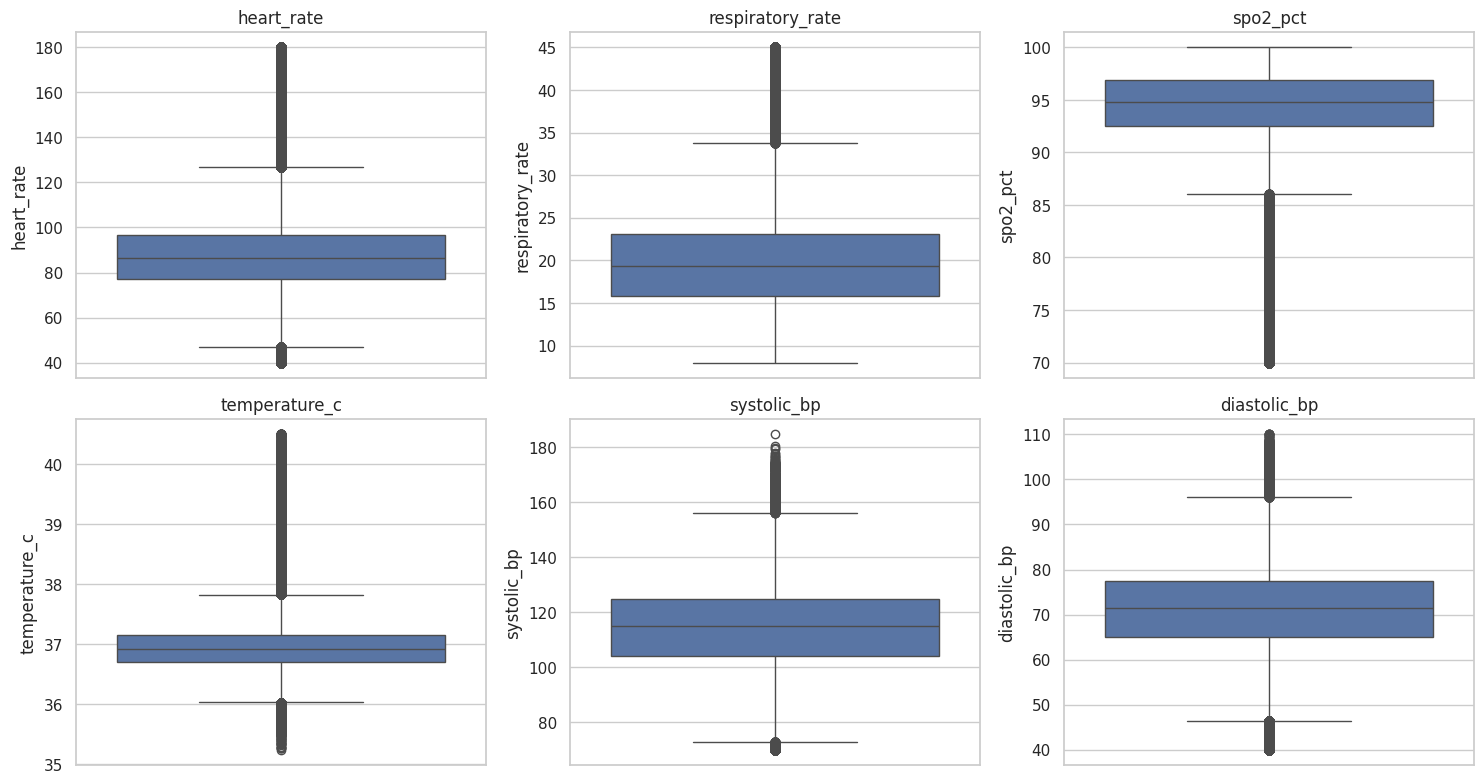

In [40]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), columnas_vitales):
    sns.boxplot(y=vitals[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [41]:
print("gender:", patients['gender'].unique())
print("admission_type:", patients['admission_type'].unique())
print("oxygen_device:", vitals['oxygen_device'].unique())

gender: ['M' 'F']
admission_type: ['Elective' 'Transfer' 'ED']
oxygen_device: ['none' 'nasal' 'mask' 'hfnc' 'niv']


In [42]:
inconsistencia_bp = (vitals['systolic_bp'] < vitals['diastolic_bp']).sum()
inconsistencia_o2 = ((vitals['oxygen_device'] == 'none') & (vitals['oxygen_flow'] > 0)).sum()
chequeo = patients[(patients['deterioration_hour'] > patients['los_hours']) & (patients['deterioration_hour'] != -1)]

print("Sistólica < diastólica:", inconsistencia_bp)
print("Dispositivo 'none' con flujo>0:", inconsistencia_o2)
print("Deterioro posterior al alta:", len(chequeo))

Sistólica < diastólica: 1231
Dispositivo 'none' con flujo>0: 0
Deterioro posterior al alta: 0


In [43]:
print((patients['deterioration_hour'] == -1).sum(), "pacientes sin evento de deterioro")

8062 pacientes sin evento de deterioro


In [44]:
# ============================================
# Fase 7 — Limpieza (ETL)
# ============================================
mask_bp_invalida = vitals['systolic_bp'] < vitals['diastolic_bp']
n_filas_invalidas = mask_bp_invalida.sum()

vitals_clean = vitals[~mask_bp_invalida].copy()
patients_clean = patients.copy()

# Alinear labs con las mismas claves válidas (versión optimizada con merge, más rápida que .apply)
labs_clean = labs.merge(
    vitals_clean[['patient_id', 'hour_from_admission']],
    on=['patient_id', 'hour_from_admission'],
    how='inner'
)

print(f"Vitals: {len(vitals)} -> {len(vitals_clean)} ({n_filas_invalidas} excluidas)")
print(f"Labs alineado: {len(labs_clean)}")
print("Duplicados PK después de limpiar:", vitals_clean.duplicated(subset=['patient_id','hour_from_admission']).sum())

Vitals: 417866 -> 416635 (1231 excluidas)
Labs alineado: 416635
Duplicados PK después de limpiar: 0


In [45]:
patients_clean.to_csv('data/processed/patients_clean.csv', index=False)
vitals_clean.to_csv('data/processed/vitals_clean.csv', index=False)
labs_clean.to_csv('data/processed/labs_clean.csv', index=False)
print("Datasets limpios guardados ✅")

Datasets limpios guardados ✅


In [46]:
# Excluir CSV de datos del control de versiones de Git (quedan solo en Drive)
with open(".gitignore", "a") as f:
    f.write("\ndata/raw/*.csv\ndata/processed/*.csv\n")

!git rm --cached data/processed/*.csv 2>/dev/null
!git add .gitignore
!git commit -m "chore: excluye CSV de datos del repo"
!git push origin main

!cp data/processed/*.csv /content/drive/MyDrive/Portfolio_Datos/clinical-deterioration-intelligence/data/processed/

[main b57e042] chore: excluye CSV de datos del repo
 1 file changed, 3 insertions(+)
Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 329 bytes | 329.00 KiB/s, done.
Total 3 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/patriciaruizpaz/clinical-deterioration-intelligence.git
   2e9f65b..b57e042  main -> main


In [47]:
# ============================================
# Fase 8 — EDA formal
# ============================================
panel = vitals_clean.merge(labs_clean, on=['patient_id', 'hour_from_admission'], how='inner')
panel = panel.merge(patients_clean, on='patient_id', how='left')

print(len(panel), panel.shape[1])
panel.to_csv('data/processed/panel_clean.csv', index=False)

416635 27


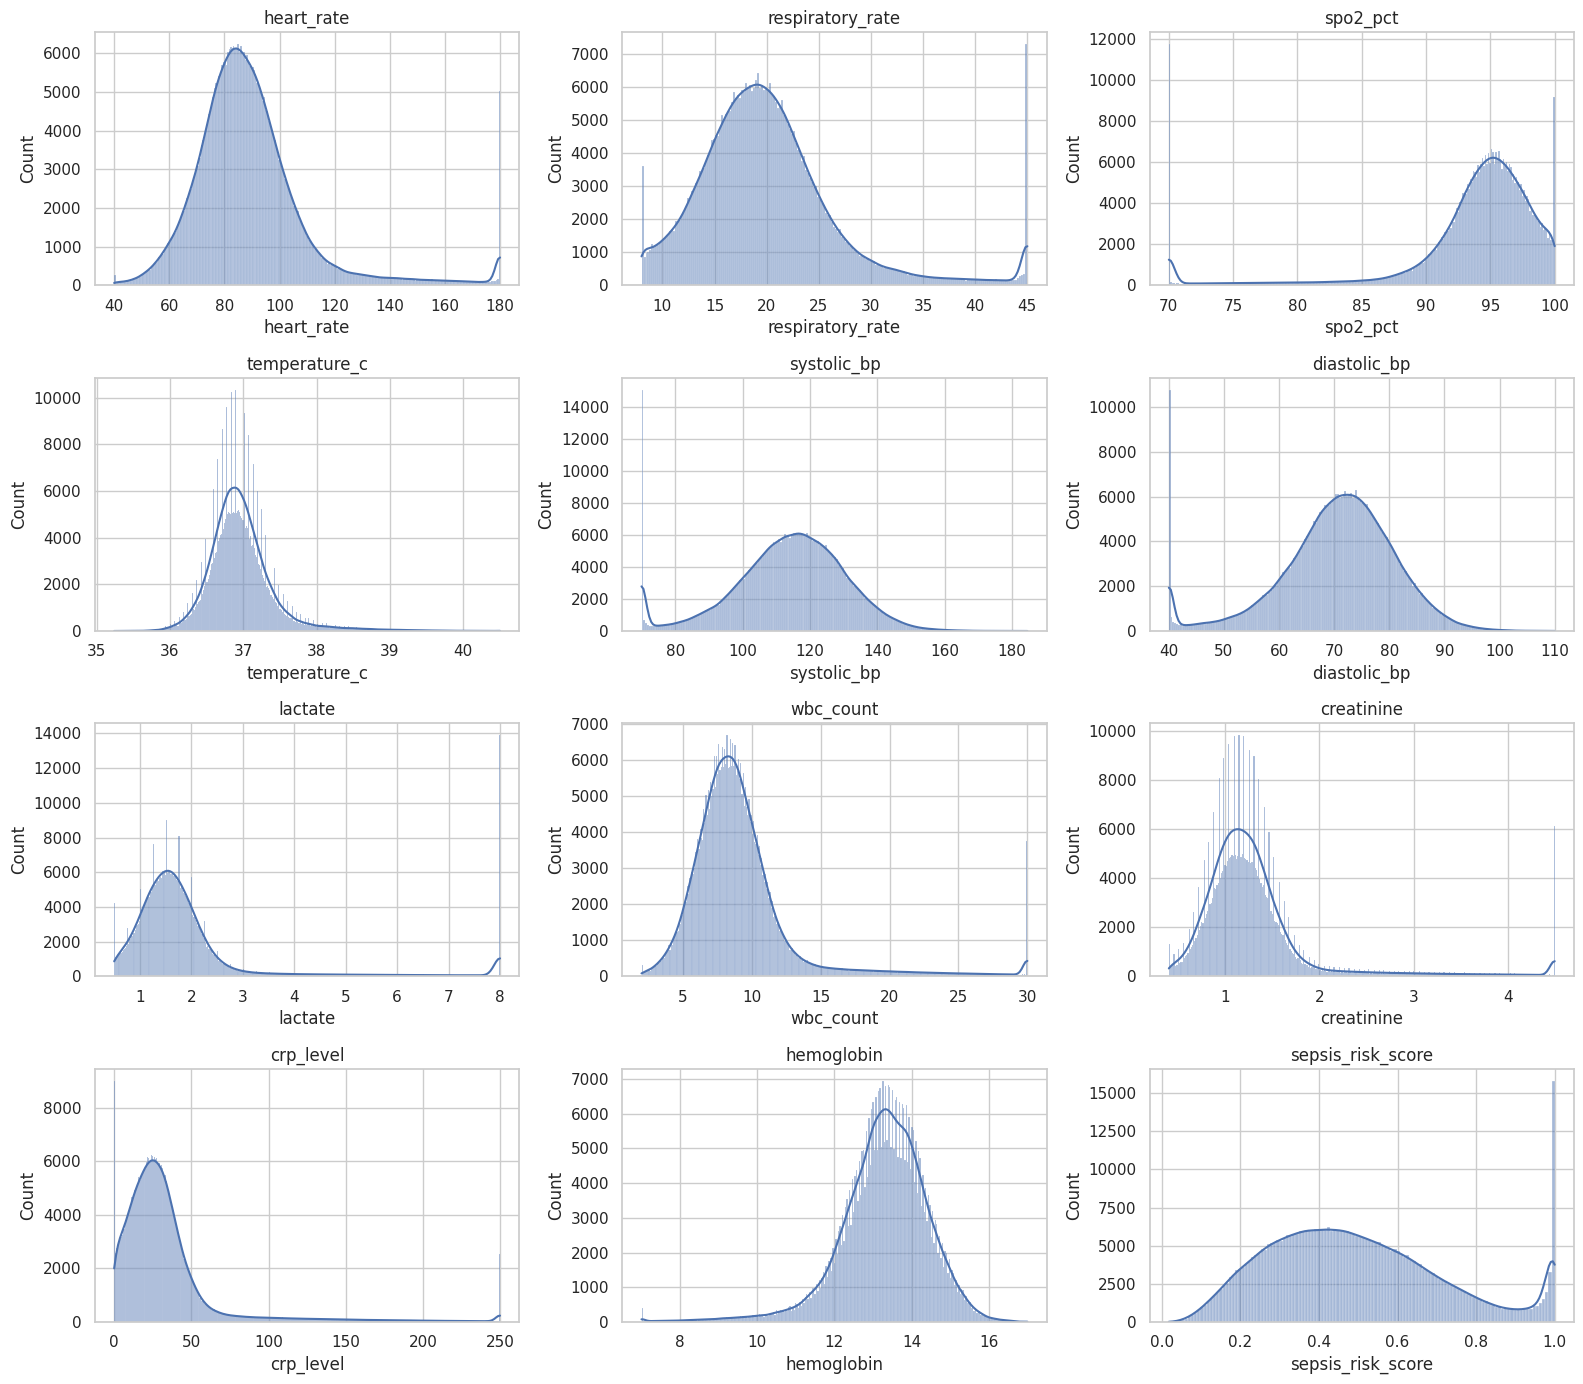

In [48]:
vars_continuas = ['heart_rate', 'respiratory_rate', 'spo2_pct', 'temperature_c',
                   'systolic_bp', 'diastolic_bp', 'lactate', 'wbc_count',
                   'creatinine', 'crp_level', 'hemoglobin', 'sepsis_risk_score']

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
for ax, col in zip(axes.flatten(), vars_continuas):
    sns.histplot(panel[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [49]:
print(patients_clean['admission_type'].value_counts(normalize=True).round(3) * 100)
print(patients_clean['deterioration_event'].value_counts(normalize=True).round(3) * 100)
print(patients_clean['deterioration_within_12h_from_admission'].value_counts(normalize=True).round(3) * 100)

admission_type
ED          64.3
Elective    25.9
Transfer     9.8
Name: proportion, dtype: float64
deterioration_event
0    80.6
1    19.4
Name: proportion, dtype: float64
deterioration_within_12h_from_admission
0    96.9
1     3.1
Name: proportion, dtype: float64


In [50]:
comparacion = panel.groupby('deterioration_event')[['spo2_pct', 'respiratory_rate', 'heart_rate', 'lactate']].agg(['mean', 'median', 'std'])
print(comparacion.round(2))

                    spo2_pct              respiratory_rate               \
                        mean median   std             mean median   std   
deterioration_event                                                       
0                      95.23  95.38  2.74            18.57  18.51  4.88   
1                      87.01  90.70  9.34            26.24  23.79  9.37   

                    heart_rate               lactate               
                          mean median    std    mean median   std  
deterioration_event                                                
0                        84.17  84.18  13.66    1.53   1.51  0.50  
1                       108.45  99.51  31.02    3.72   2.55  2.49  


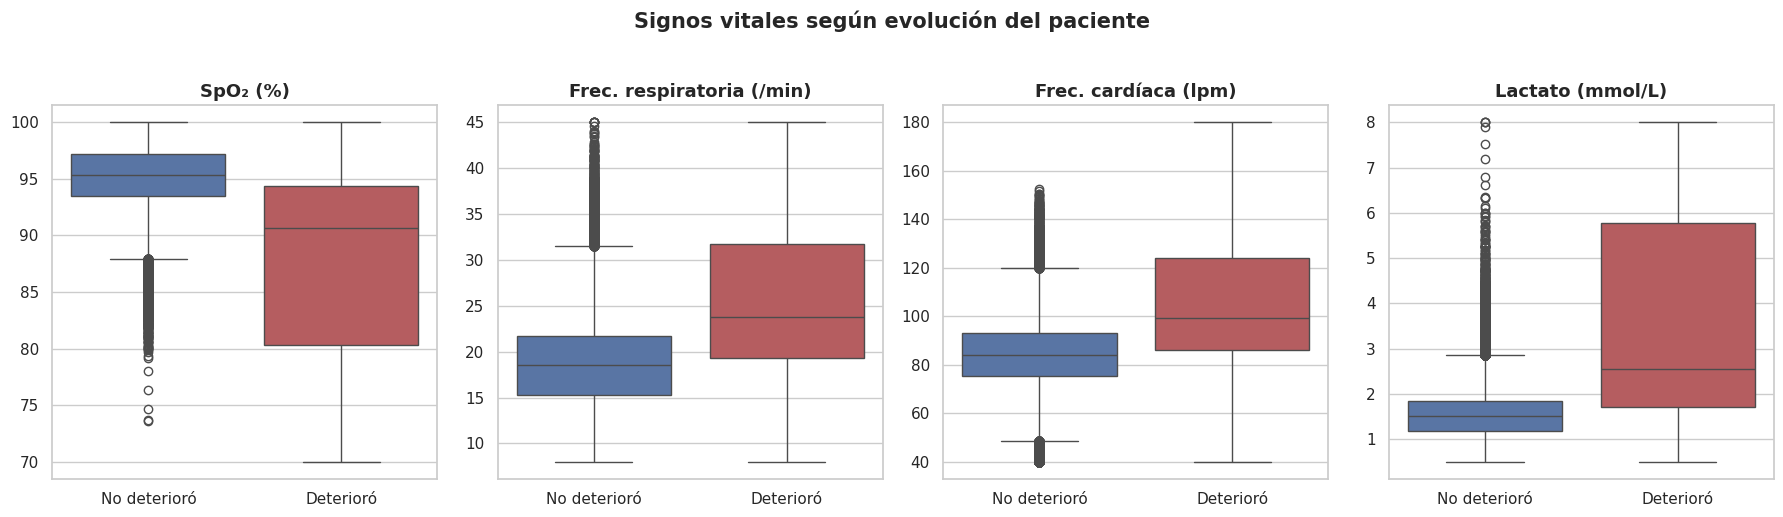

In [51]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
variables = ['spo2_pct', 'respiratory_rate', 'heart_rate', 'lactate']
titulos = ['SpO₂ (%)', 'Frec. respiratoria (/min)', 'Frec. cardíaca (lpm)', 'Lactato (mmol/L)']

for ax, col, titulo in zip(axes, variables, titulos):
    sns.boxplot(data=panel, x='deterioration_event', y=col, hue='deterioration_event',
                palette=['#4C72B0', '#C44E52'], legend=False, ax=ax)
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No deterioró', 'Deterioró'], fontsize=11)

plt.suptitle('Signos vitales según evolución del paciente', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('boxplot_deterioro.png', dpi=200, bbox_inches='tight')
plt.show()

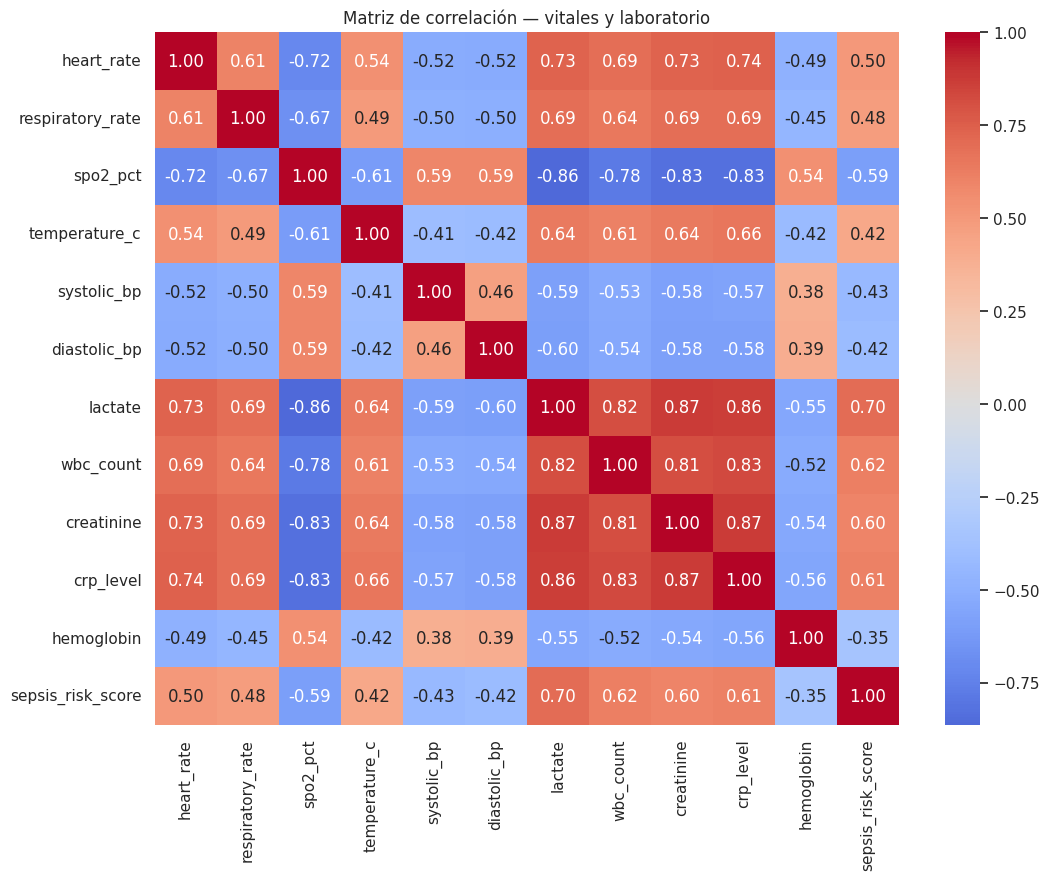

In [52]:
matriz_corr = panel[vars_continuas].corr()
plt.figure(figsize=(12, 9))
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlación — vitales y laboratorio')
plt.show()

In [53]:
for col in ['spo2_pct', 'respiratory_rate', 'lactate']:
    stat, p_valor = stats.shapiro(panel[col].sample(5000, random_state=42))
    print(f"{col}: estadístico={stat:.4f}, p-valor={p_valor:.6f}")

spo2_pct: estadístico=0.7301, p-valor=0.000000
respiratory_rate: estadístico=0.9121, p-valor=0.000000
lactate: estadístico=0.6280, p-valor=0.000000


In [54]:
# Correlación comorbidity_index vs baseline_risk_score (Fase 9)
correlacion_comorb_riesgo = patients_clean[['comorbidity_index', 'baseline_risk_score']].corr()
print(correlacion_comorb_riesgo)

                     comorbidity_index  baseline_risk_score
comorbidity_index             1.000000             0.695663
baseline_risk_score           0.695663             1.000000


In [55]:
# Traer deterioration_next_12h (target a nivel hora) desde el archivo oficial,
# uniéndolo a TU panel construido a mano — no reemplazamos tu trabajo, lo completamos.
hourly_panel_full = pd.read_csv(ruta + 'hospital_deterioration_hourly_panel.csv')

panel_con_target = panel.merge(
    hourly_panel_full[['patient_id', 'hour_from_admission', 'deterioration_next_12h']],
    on=['patient_id', 'hour_from_admission'],
    how='left'
)

print("Filas con target nulo (sin match):", panel_con_target['deterioration_next_12h'].isnull().sum())
print("Distribución del target:")
print(panel_con_target['deterioration_next_12h'].value_counts(normalize=True).round(4) * 100)

panel_con_target.to_csv('data/processed/panel_con_target.csv', index=False)

Filas con target nulo (sin match): 0
Distribución del target:
deterioration_next_12h
0    94.61
1     5.39
Name: proportion, dtype: float64


In [56]:
# Confirmar y dejar registrado el archivo definitivo para las preguntas 1, 2 y 7
print("Panel con target a nivel hora:", panel_con_target.shape)
print(panel_con_target['deterioration_next_12h'].value_counts())

# Guardar también en Drive, igual que el resto de processed/
!cp data/processed/panel_con_target.csv /content/drive/MyDrive/Portfolio_Datos/clinical-deterioration-intelligence/data/processed/

Panel con target a nivel hora: (416635, 28)
deterioration_next_12h
0    394169
1     22466
Name: count, dtype: int64
